# Analysis of Experiment Results

## Setup

In [1]:
import json
from pathlib import Path
import matplotlib.pyplot as plt
import scienceplots


plt.style.use(["science", "no-latex"])

def load_experiment_results(json_path: str) -> list[dict]:
    path = Path(json_path)
    with path.open("r", encoding="utf-8") as f:
        data = json.load(f)
    return data

ModuleNotFoundError: No module named 'scienceplots'

In [6]:
EXPERIMENT_NAMES = {
    "random_sampling_initial_100_query_100",
    "random_sampling_initial_100_query_1000",
    "random_sampling_initial_1000_query_1000",
    "uncertainty_sampling_initial_1000_query_1000",
    "uncertainty_sampling_initial_100_query_100",
    }



experiment_results = {}
for exp_name in EXPERIMENT_NAMES:
    json_path = f"/mnt/ssd2/zachary/alpes/experiments/{exp_name}/experiment_results.json"
    experiment_results[exp_name] = load_experiment_results(json_path)

VALID_KEYS = [
    "iteration",
    "no_of_samples",
    "no_of_frames",
    "non_bg_percentage",
    "best_epoch",
    "mean_f1_event",
    "mean_f1_element",
    "edit"
]


def show_graph(exp_names, x_axis, y_axis):
    if x_axis not in VALID_KEYS:
        raise ValueError(f"`{x_axis}` is not a valid key")
    
    if y_axis not in VALID_KEYS:
        raise ValueError(f"`{y_axis}` is not a valid key")
    
    plt.figure()

    for exp_name in exp_names:
        results = experiment_results[exp_name]
        results_sorted = sorted(results, key=lambda x: x[x_axis])

        x = [r[x_axis] for r in results_sorted]
        y = [r[y_axis] for r in results_sorted]

        plt.plot(x, y, marker="o", label=exp_name)


    plt.title(f"{x_axis} vs. {y_axis}")
    plt.xlabel(x_axis)
    plt.ylabel(y_axis)
    plt.legend()
    plt.grid(True)
    plt.show()

## Initial 100 + Query 100 (Performance vs. Amount of Data)

In [7]:
INITIAL_100_QUERY_100 = [
    "random_sampling_initial_100_query_100",
    "uncertainty_sampling_initial_100_query_100"
    ]

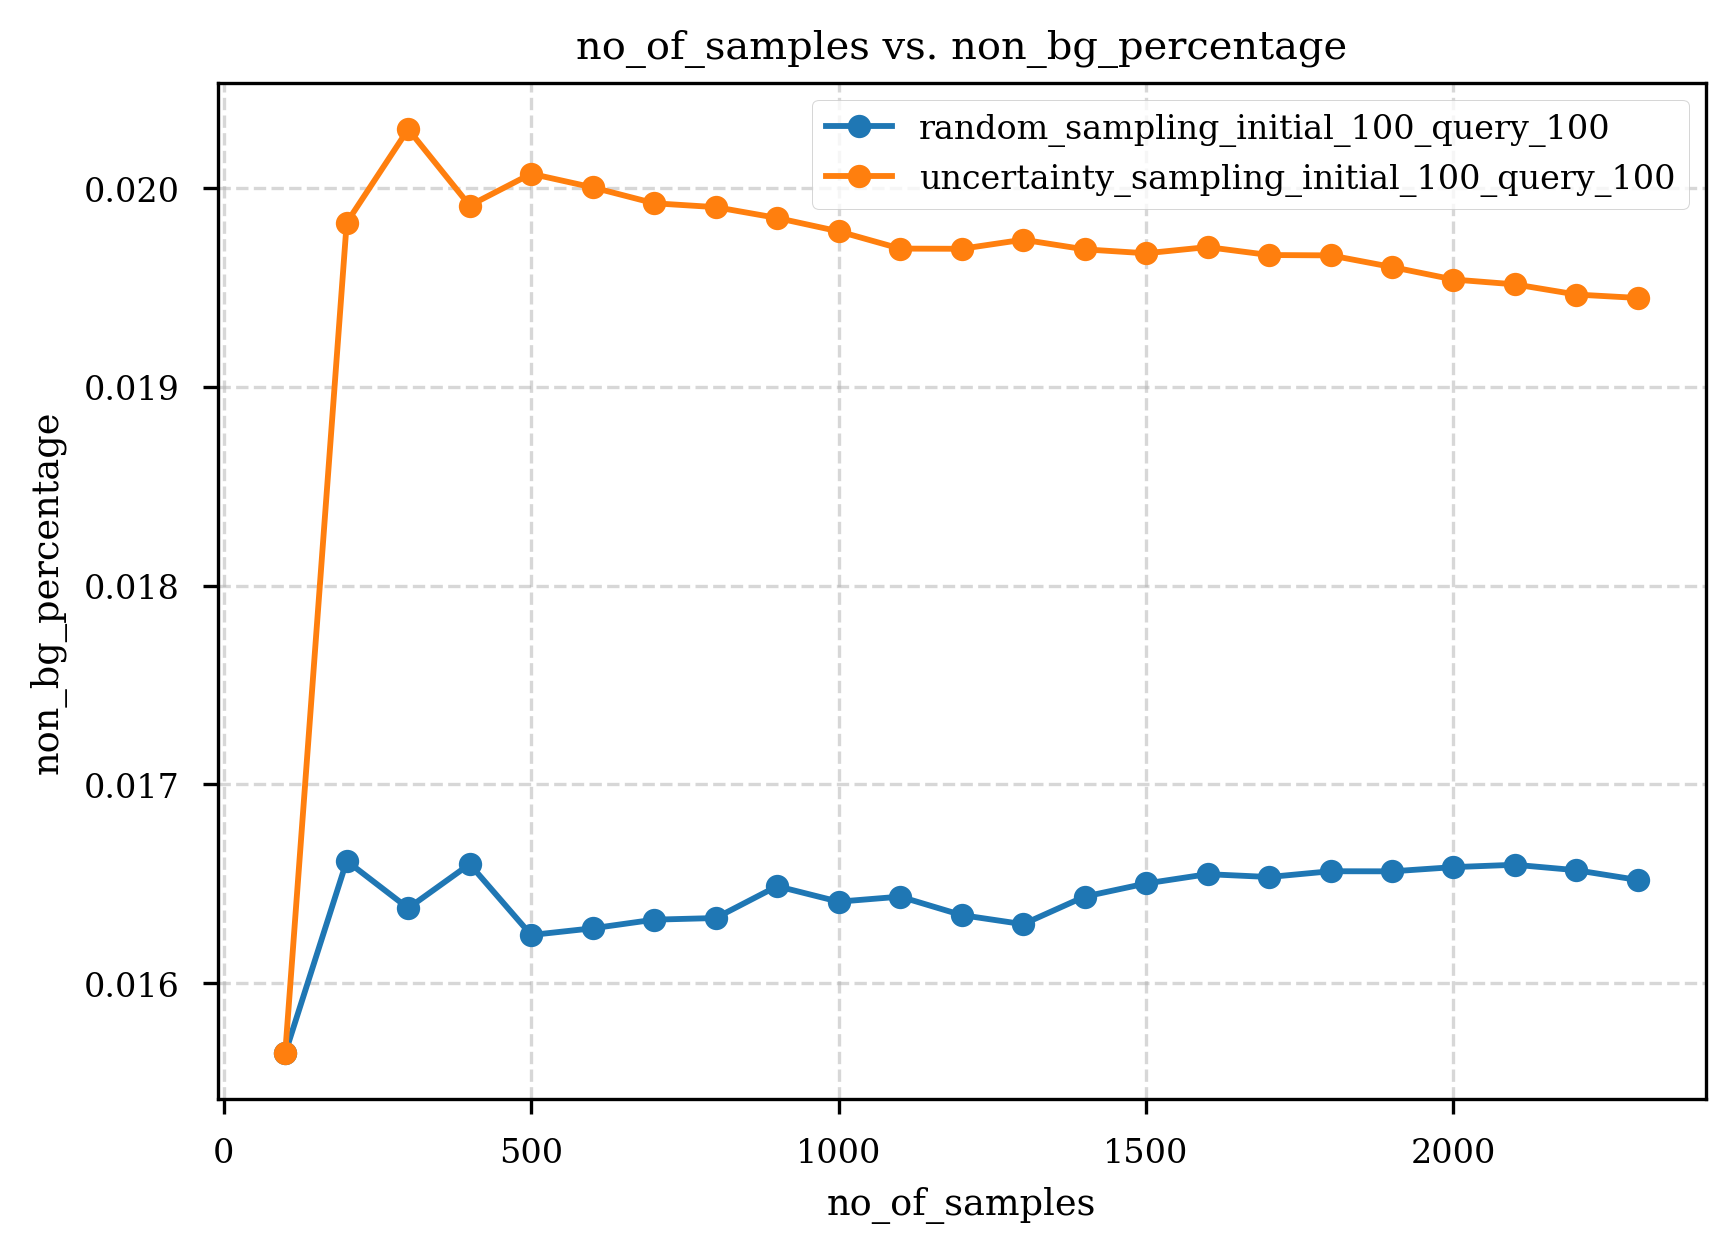

In [8]:
# Uncertainty sampling tends to choose samples with overall higher non_bg_percentage
show_graph(INITIAL_100_QUERY_100, x_axis="no_of_samples", y_axis="non_bg_percentage")


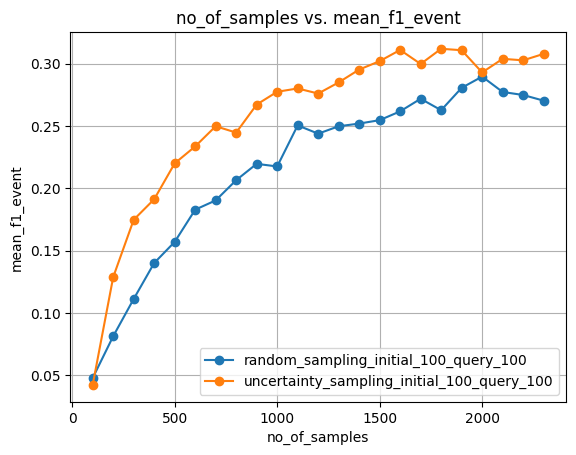

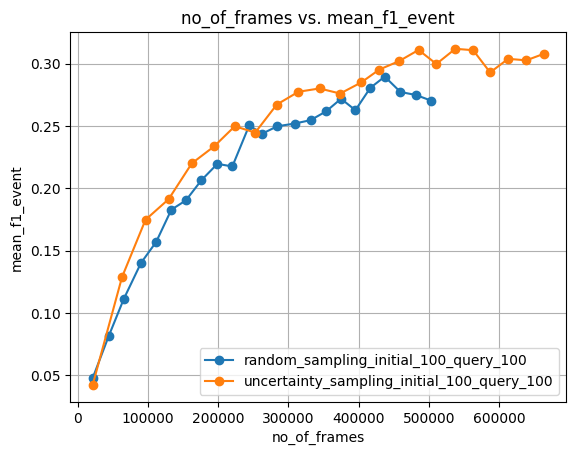

In [83]:
# Mean F1 Event
show_graph(INITIAL_100_QUERY_100, x_axis="no_of_samples", y_axis="mean_f1_event")
show_graph(INITIAL_100_QUERY_100, x_axis="no_of_frames", y_axis="mean_f1_event")

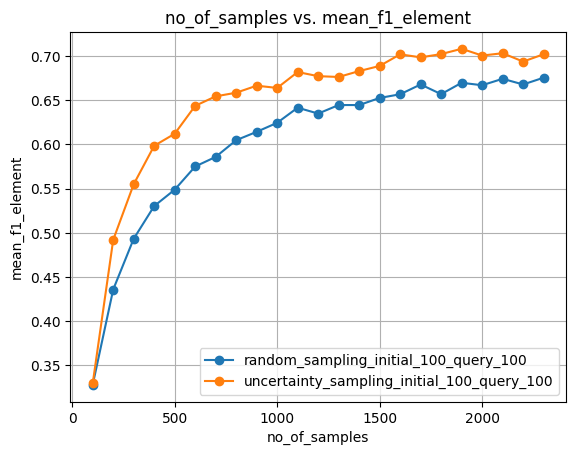

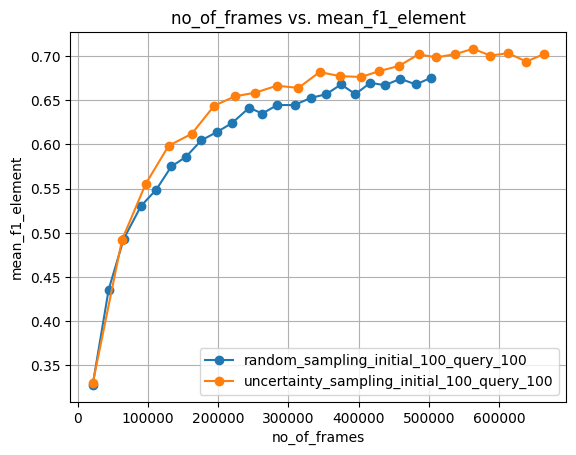

In [92]:
# Mean F1 Element
# Might be more accurate/representative since it's the number of frames that actually matters for training
show_graph(INITIAL_100_QUERY_100, x_axis="no_of_samples", y_axis="mean_f1_element")
show_graph(INITIAL_100_QUERY_100, x_axis="no_of_frames", y_axis="mean_f1_element")

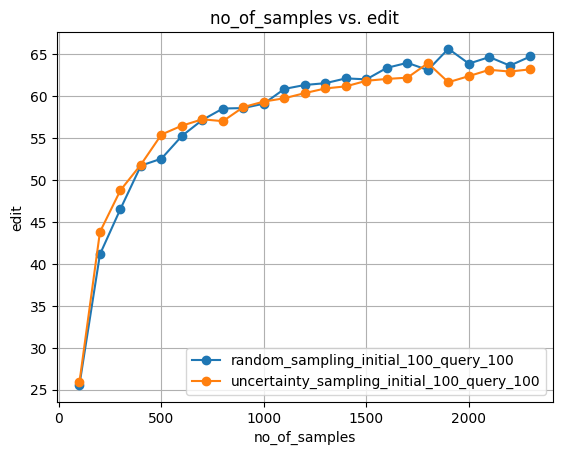

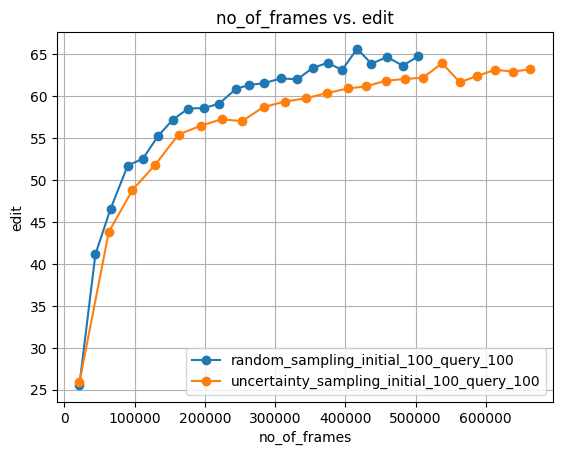

In [94]:
# Edit Score
show_graph(INITIAL_100_QUERY_100, x_axis="no_of_samples", y_axis="edit")
show_graph(INITIAL_100_QUERY_100, x_axis="no_of_frames", y_axis="edit")

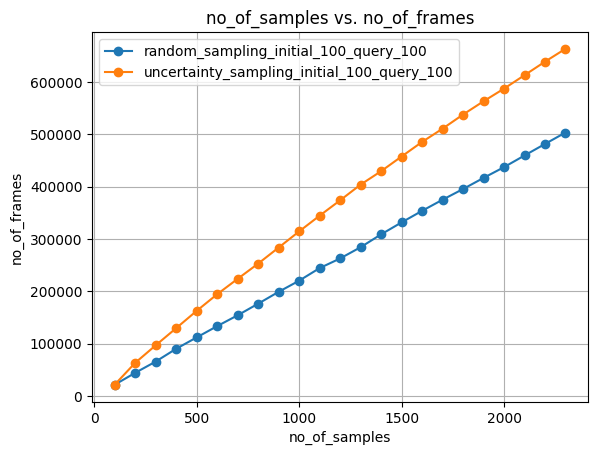

In [95]:
# How many total frames were selected?
show_graph(INITIAL_100_QUERY_100, x_axis="no_of_samples", y_axis="no_of_frames")

## Initial 1000 + Query 1000 (Performance vs. Amount of Data)

In [89]:
INITIAL_1000_QUERY_1000 = [
    # "random_sampling_initial_100_query_1000",
    "random_sampling_initial_1000_query_1000",
    "uncertainty_sampling_initial_1000_query_1000"
    ]

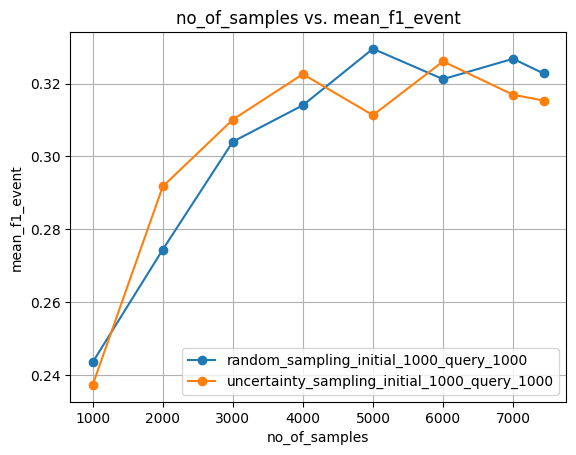

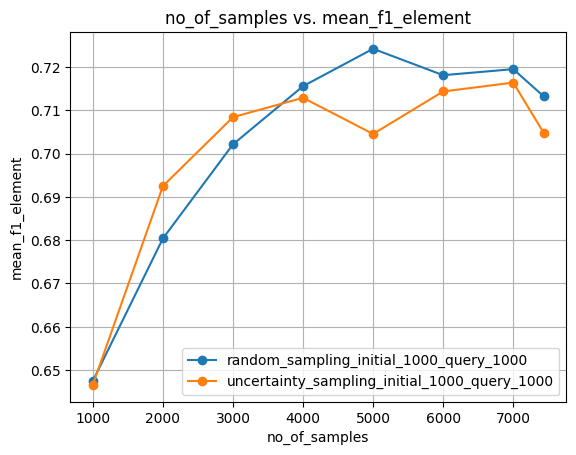

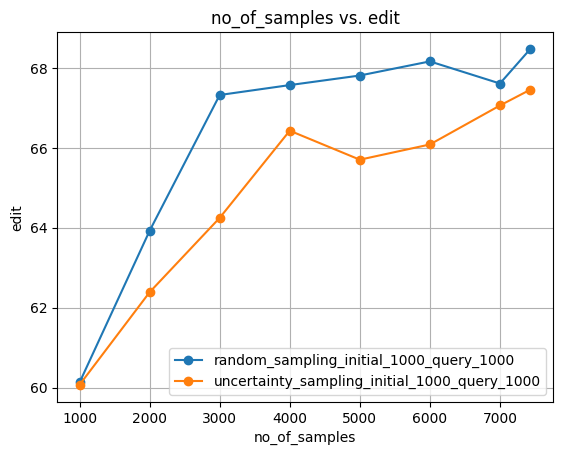

In [90]:
show_graph(INITIAL_1000_QUERY_1000, x_axis="no_of_samples", y_axis="mean_f1_event")
show_graph(INITIAL_1000_QUERY_1000, x_axis="no_of_samples", y_axis="mean_f1_element")
show_graph(INITIAL_1000_QUERY_1000, x_axis="no_of_samples", y_axis="edit")

## Query Batch Analysis

In [107]:
results = []

for i in range(23):
    json_path = Path(f"/mnt/ssd2/zachary/alpes/experiments/uncertainty_sampling_initial_100_query_100/active_learning_iteration_{i}/query_batch.json")
    with json_path.open("r", encoding="utf-8") as f:
        data = json.load(f)

    results.append([x[1] for x in data])
    

mins = [min(sublist) for sublist in results]
print(mins)

[0.4986572265625, 0.49609375, 0.49609375, 0.495574951171875, 0.494873046875, 0.49609375, 0.49365234375, 0.49609375, 0.4940185546875, 0.4945068359375, 0.494140625, 0.4951171875, 0.49365234375, 0.49560546875, 0.49560546875, 0.49462890625, 0.49365234375, 0.4932861328125, 0.49462890625, 0.4927978515625, 0.4930877685546875, 0.49365234375, 0.49365234375]


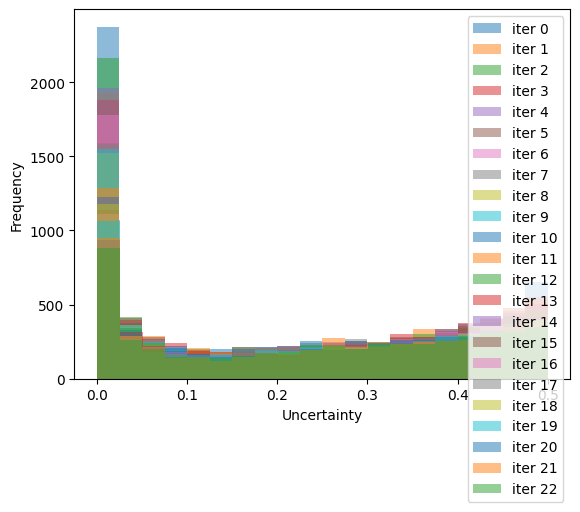

In [ ]:
import numpy as np
from pprint import pprint
import matplotlib.pyplot as plt

all_uncertainty_values = []

for i in range(23):
    json_path = Path(f"/mnt/ssd2/zachary/alpes/experiments/uncertainty_sampling_initial_100_query_100/active_learning_iteration_{i}/max_uncertainty_per_video.json")
    with json_path.open("r", encoding="utf-8") as f:
        data = json.load(f)
    all_uncertainty_values.append(list(data.values()))

print(all_uncertainty_values)

histograms = [
    np.histogram(values, bins=20)  # (counts, bin_edges)
    for values in all_uncertainty_values
]


for i, values in enumerate(all_uncertainty_values):
    plt.hist(values, bins=20, alpha=0.5, label=f"iter {i}")

plt.legend()
plt.xlabel("Uncertainty")
plt.ylabel("Frequency")
plt.show()
    

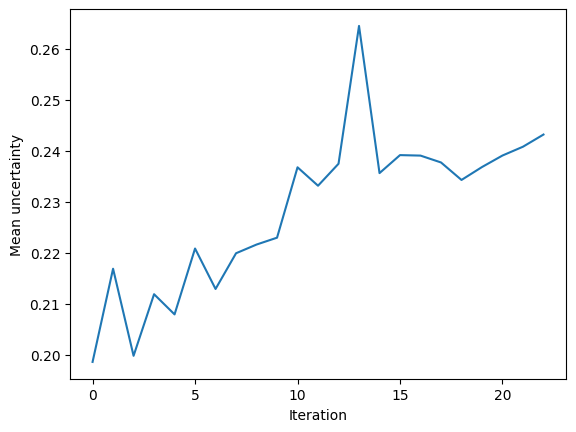

In [127]:
means = [sum(v)/len(v) for v in all_uncertainty_values]

plt.plot(means)
plt.xlabel("Iteration")
plt.ylabel("Mean uncertainty")
plt.show()

## Generating Graphs